In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


deliveries_df = pd.read_csv('/content/deliveries.csv')
matches_df = pd.read_csv('/content/matches.csv')

### Calculate 1st Innings Scores

In [39]:

first_innings_scores = deliveries_df[deliveries_df['inning'] == 1]


first_innings_scores = first_innings_scores.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()

print('First 5 rows of calculated first_innings_scores:')
display(first_innings_scores.head())

First 5 rows of calculated first_innings_scores:


,match_id,batting_team,total_runs
0,335982,Kolkata Knight Riders,222
1,335983,Chennai Super Kings,240
2,335984,Rajasthan Royals,129
3,335985,Mumbai Indians,165
4,335986,Deccan Chargers,110


### Merge Scores with Match Type and Define Match Phase

In [52]:

merged_scores = pd.merge(first_innings_scores, matches_df[['id', 'match_type']], left_on='match_id', right_on='id', how='left')

merged_scores['match_phase'] = merged_scores['match_type'].apply(
    lambda x: 'Playoff/Final' if any(keyword in x for keyword in ['Final', 'Qualifier', 'Qualifier 1', 'Qualifier 2', 'Eliminator', 'Semi Final', 'Elimination Final', '3rd Place Play-Off'])
    else 'Regular Season'
)

print('First 5 rows of merged_scores with match_phase:')
display(merged_scores.head())

First 5 rows of merged_scores with match_phase:


,match_id,batting_team,total_runs,id,match_type,match_phase
0,335982,Kolkata Knight Riders,222,335982,League,Regular Season
1,335983,Chennai Super Kings,240,335983,League,Regular Season
2,335984,Rajasthan Royals,129,335984,League,Regular Season
3,335985,Mumbai Indians,165,335985,League,Regular Season
4,335986,Deccan Chargers,110,335986,League,Regular Season


### Calculate Team Statistics (Median, Variance, IQR)

In [53]:

team_stats = merged_scores.groupby('batting_team')['total_runs'].agg(['median', 'var']).reset_index()
print('Team Statistics (Median and Variance of 1st Innings Scores):')
display(team_stats.head())


team_highest_median = team_stats.loc[team_stats['median'].idxmax()]
team_widest_variance = team_stats.loc[team_stats['var'].idxmax()]

print(f"\nTeam with the highest median 1st innings score: {team_highest_median['batting_team']} (Median: {team_highest_median['median']:.2f})")
print(f"Team with the widest variance in 1st innings scores: {team_widest_variance['batting_team']} (Variance: {team_widest_variance['var']:.2f})")


team_iqr = merged_scores.groupby('batting_team')['total_runs'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25)).reset_index(name='IQR')
print('\nTeam Statistics (Interquartile Range of 1st Innings Scores):')
display(team_iqr.head())

team_widest_iqr = team_iqr.loc[team_iqr['IQR'].idxmax()]
print(f"Team with the widest Interquartile Range in 1st innings scores: {team_widest_iqr['batting_team']} (IQR: {team_widest_iqr['IQR']:.2f})")

Team Statistics (Median and Variance of 1st Innings Scores):


,batting_team,median,var
0,Chennai Super Kings,169.0,978.631843
1,Deccan Chargers,164.0,731.415282
2,Delhi Capitals,162.0,1031.390244
3,Delhi Daredevils,160.0,1168.871479
4,Gujarat Lions,159.5,540.532967



Team with the highest median 1st innings score: Royal Challengers Bengaluru (Median: 187.00)
Team with the widest variance in 1st innings scores: Gujarat Titans (Variance: 1317.86)

Team Statistics (Interquartile Range of 1st Innings Scores):


,batting_team,IQR
0,Chennai Super Kings,41.25
1,Deccan Chargers,34.50
2,Delhi Capitals,38.00
3,Delhi Daredevils,41.00
4,Gujarat Lions,25.00


Team with the widest Interquartile Range in 1st innings scores: Punjab Kings (IQR: 50.50)


### Calculate 1st Innings Average Score Distribution by Team and Match Phase

In [54]:
average_scores_distribution = merged_scores.groupby(['batting_team', 'match_phase'])['total_runs'].mean().reset_index()
print('Average 1st Innings Score Distribution by Match Phase:')
display(average_scores_distribution.head())


playoff_scores = merged_scores[merged_scores['match_phase'] == 'Playoff/Final']
team_playoff_median = playoff_scores.groupby('batting_team')['total_runs'].median().reset_index()

print('\nMedian 1st Innings Scores in Playoff/Final Matches:')
display(team_playoff_median.head())

highest_median_playoff = team_playoff_median.loc[team_playoff_median['total_runs'].idxmax()]
print(f"Team with the highest median 1st innings score in Playoff/Final matches: {highest_median_playoff['batting_team']} (Median: {highest_median_playoff['total_runs']:.2f})")

Average 1st Innings Score Distribution by Match Phase:


,batting_team,match_phase,total_runs
0,Chennai Super Kings,Playoff/Final,175.833333
1,Chennai Super Kings,Regular Season,169.338983
2,Deccan Chargers,Playoff/Final,112.500000
3,Deccan Chargers,Regular Season,159.512195
4,Delhi Capitals,Playoff/Final,159.800000



Median 1st Innings Scores in Playoff/Final Matches:


,batting_team,total_runs
0,Chennai Super Kings,179.5
1,Deccan Chargers,112.5
2,Delhi Capitals,156.0
3,Delhi Daredevils,153.0
4,Gujarat Lions,160.0


Team with the highest median 1st innings score in Playoff/Final matches: Gujarat Titans (Median: 223.50)


### Visualization: Distribution of 1st Innings Scores by Team and Match Phase

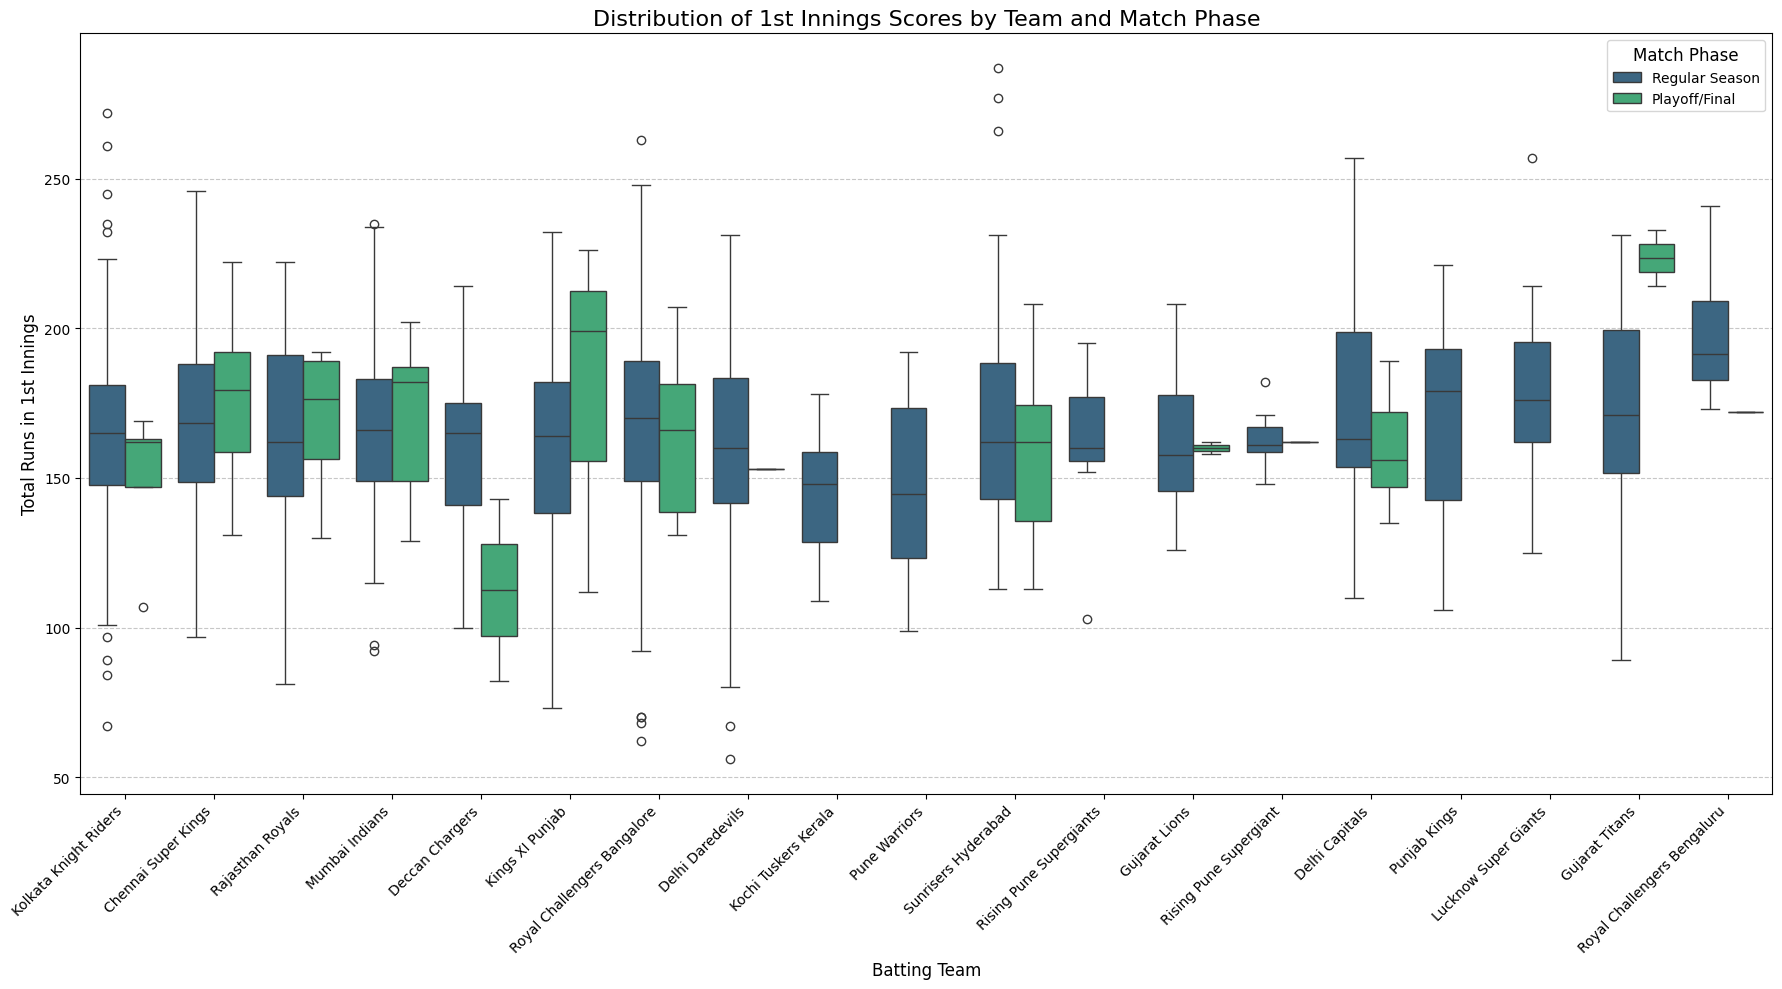

In [55]:
plt.figure(figsize=(18, 10))
sns.boxplot(x='batting_team', y='total_runs', hue='match_phase', data=merged_scores, palette='viridis')
plt.title('Distribution of 1st Innings Scores by Team and Match Phase', fontsize=16)
plt.xlabel('Batting Team', fontsize=12)
plt.ylabel('Total Runs in 1st Innings', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Match Phase', title_fontsize='12', fontsize='10')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()